<img src="../img/GTK_Logo_Social Icon.jpg" width=175 align="right" />

# Worksheet 3.1: Feature Engineering - Answers
This worksheet covers concepts covered in the first part of the Feature Engineering module.  It should take no more than 30-40 minutes to complete.  Please raise your hand if you get stuck.  

## Import the Libraries
For this exercise, we will be using:
* Pandas (http://pandas.pydata.org/pandas-docs/stable/)
* Numpy (https://docs.scipy.org/doc/numpy/reference/)
* Matplotlib (https://matplotlib.org/)
* Seaborn (https://seaborn.pydata.org)
* YData Profiling (Optional): (https://ydata-profiling.ydata.ai/docs/master/index.html)

In [30]:
# Load Libraries - Make sure to run this cell!
import pandas as pd
import numpy as np
import re
import seaborn as sns
import pickle
import matplotlib.pyplot as plt

DATA_HOME = '../data/'

## Load Data

In [2]:
## Load data
full_df = pd.read_csv(f'{DATA_HOME}/dga_data_small.csv')
full_df.head()

,isDGA,domain,host,subclass
0,dga,tyopcrkqgxcfm,tyopcrkqgxcfm.co.uk,cryptolocker
1,dga,72j5rn1l9mzleo6203v1ogenfl,72j5rn1l9mzleo6203v1ogenfl.org,gameoverdga
2,dga,thenrest,thenrest.net,nivdort
3,dga,15ihbm71utcnfa8dk1mmgoobl9,15ihbm71utcnfa8dk1mmgoobl9.org,gameoverdga
4,dga,x1d6ou7e7kofk60ayhq74x7e,x1d6ou7e7kofk60ayhq74x7e.net,gameoverdga


In [3]:
full_df.drop(['host', 'subclass'], axis='columns', inplace=True)
print("(Total Rows, Total Cols)")
print(full_df.shape)

(Total Rows, Total Cols)
(2000, 2)


In [4]:
# print a random sample of the DataFrame
full_df.sample(5)

,isDGA,domain
1655,legit,bbsgayru
124,dga,llcuslxdls9jv2hxzi160gin3
964,dga,rtgdcqblkuwfrvv
740,dga,imxdwdscghyqtik
1571,legit,propay


In [5]:
# print a sample of dga domains via filtering
full_df[full_df.isDGA == 'dga'].sample(5)

,isDGA,domain
282,dga,uyy729lzzchgzwa94tdl0do8
651,dga,mhoxbfsphqmg
588,dga,pblbnlfsovvpe
134,dga,uqdruplruuohb
97,dga,ixdeythowshsj


## Part 1 - Feature Engineering

Option 1 to derive Machine Learning features is to manually hand-craft useful contextual information of the domain string.

Previous academic research has focused on the following features that are based on contextual information:

**List of features**:

1. Length ["length"]
2. Number of digits ["digits"]
3. Entropy ["entropy"] - use ```H_entropy``` function provided 
4. Vowel to consonant ratio ["vowel-cons"] - use ```vowel_consonant_ratio``` function provided
5. The index of the first digit - use the ``firstDigitIndex`` function provided
5. N-grams ["n-grams"] - use ```ngram``` functions provided

**Tasks**:    
Split into A and B parts, see below...


Please run the following function cell and then continue reading the next markdown cell with more details on how to derive those features. Have fun!

In [6]:
def H_entropy (x):
    # Calculate Shannon Entropy
    prob = [ float(x.count(c)) / len(x) for c in dict.fromkeys(list(x)) ] 
    H = - sum([ p * np.log2(p) for p in prob ]) 
    return H

def firstDigitIndex(s):
    for i, c in enumerate(s):
        if c.isdigit():
            return i + 1
    return 0

def vowel_consonant_ratio (x):
    # Calculate vowel to consonant ratio
    x = x.lower()
    vowels_pattern = re.compile('([aeiou])')
    consonants_pattern = re.compile('([b-df-hj-np-tv-z])')
    vowels = re.findall(vowels_pattern, x)
    consonants = re.findall(consonants_pattern, x)
    try:
        ratio = len(vowels) / len(consonants)
    except: # catch zero devision exception 
        ratio = 0  
    return ratio

### Task A: Derive new features

Please try to derive a new pandas 2D DataFrame with a new column for each of feature. Focus on 
1. Length ["length"]
2. Number of digits ["digits"]
3. Entropy ["entropy"] - use ```H_entropy``` function provided 
4. Vowel to consonant ratio ["vowel-cons"] - use ```vowel_consonant_ratio``` function provided
5. The index of the first digit - use the ``firstDigitIndex`` function provided

[pandas.Series.str](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.html#pandas.Series.str), [pandas.Series.replace](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.replace.html) and [pandas.Series,apply](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.apply.html) can be very helpful to quickly derive those features. Functions you need to apply here are provided in above cell.

In [7]:
# derive features
full_df['length'] = full_df['domain'].str.len()
full_df['digits'] = full_df['domain'].str.count('[0-9]')
full_df['entropy'] = full_df['domain'].apply(H_entropy)
full_df['vowel-cons'] = full_df['domain'].apply(vowel_consonant_ratio)
full_df['firstDigitIndex'] = full_df['domain'].apply(firstDigitIndex)

print(full_df['isDGA'].value_counts())

# check intermediate 2D pandas DataFrame
full_df.sample(n=5).head()


isDGA
dga      1000
legit    1000
Name: count, dtype: int64


,isDGA,domain,length,digits,entropy,vowel-cons,firstDigitIndex
1308,legit,tvxs,4,0,2.000000,0.000000,0
1386,legit,crashonline,11,0,3.277613,0.571429,0
1250,legit,thethaovanhoa,13,0,2.661226,0.857143,0
1472,legit,parkwind,8,0,3.000000,0.333333,0
603,dga,6gwa14e99ask1wmixxpuoxakt,25,6,3.943465,0.583333,1


### Tasks - B - Feature Engineering

Finally, let's tackle the **ngram** feature. There are multiple steps involved to derive this feature. Here in this notebook, we use an implementation outlined in the this academic paper [Schiavoni 2014: "Phoenix: DGA-based Botnet Tracking and Intelligence" - see section: Linguistic Features](https://seclab.cs.ucsb.edu/files/publications/Schiavoni2014Phoenix_DGA-Based.pdf).


- **What are ngrams???** Imagine a string like 'facebook', if I were to derive all n-grams for n=2 (aka bi-grams) I would get '['fa', 'ac', 'ce', 'eb', 'bo', 'oo', 'ok']', so you see that you slide with one step from the left and just group 2 characters together each time, a tri-gram for 'facebook' would yielfd '['fac', 'ace', 'ceb', 'ebo', 'boo', 'ook']'. Ngrams have a long history in natural language processing, but are also used a lot for example in detecting malicious executable (raw byte ngrams in this case).

Steps involved:

1. We have the 10000 most common english words (see data file we loaded, we call this DataFrame ```top_en_words```). Now we run the ```ngrams``` functions on a list of all these words. The output here is a list that contains ALL 1-grams, bi-grams and tri-grams of these 10000 most common english words.
2. We used the ```Counter``` function from collections to derive a dictionary ```ngram_common_dict``` that contains the counts of all unique 1-grams, bi-grams and tri-grams.
3. Our ```ngram_feature``` function will do the core magic. It takes your domain as input, splits it into ngrams (n is a function parameter) and then looks up these ngrams in the english dictionary ```ngram_common_dict```. Function returns the normalized sum of all ngrams that were contained in the english dictionary. For example, running ```ngram_feature('facebook', d, 2)``` will return 171.28 (this value is just like the one published in the Schiavoni paper).
4. Finally ```average_ngram_feature``` wraps around ```ngram_feature```. All it does is take the average of a list of numbers b/c your task is to derive a feature that gives the average of the ngram_feature for three different values of ```n``` n=1,2,3.    
5. **YOUR TURN: Apply ```average_ngram_feature``` to you domain column in the DataFrame thereby adding ```ngram``` to the full_df.**
6. **YOUR TURN: Finally drop the ```domain``` column from your DataFrame**.

## Step 1
We have the 10000 most common english words ```top_en_words```.  Load this .txt file using the Pandas read_csv function and print 5 random rows of the dataframe. 

In [8]:
# Google's 10000 most common english words will be needed to derive a feature called ngrams

top_en_words = pd.read_csv(f'{DATA_HOME}google-10000-english.txt', header=None, names=['words'])
top_en_words.sample(n=5)

,words
8323,promises
7098,boxing
3055,attempt
4919,bread
847,edit


## Step 2
We used the ```Counter``` function from collections to derive a dictionary that contains the counts of all unique 1-grams, bi-grams and tri-grams in the file you loaded above [common english source](https://github.com/first20hours/google-10000-english). 

This is saved as ```d_common_en_words.pickle``` in the ```/data``` directory. 

Load this dictionary into a variable called ```ngram_common_dict```

In [9]:
with open(f'{DATA_HOME}d_common_en_words' + '.pickle', 'rb') as f:
        ngram_common_dict = pickle.load(f)
#ngram_common_dict

## Step 3
Define functions to calculate the average ngram feature for a given word (domain). We have created the functions below, you just need to run the cell. 

In [10]:
# Schiavoni 2014: "Phoenix: DGA-based Botnet Tracking and Intelligence" - see section: Linguistic Features
# https://seclab.cs.ucsb.edu/files/publications/Schiavoni2014Phoenix_DGA-Based.pdf

def ngrams(word, n):
    '''
    Extract n ngrams from each word and return a regular Python list
    
    Input 
    word: (string) or a (list) of strings
    n: (integer) or a (list) of integers, lenght of ngram

    Output: 
    
    '''
    
    list_ngrams = []
    if isinstance(word, list):
        for w in word:
            if isinstance(n, list):
                for curr_n in n:
                    ngrams = [w[i:i+curr_n] for i in range(0,len(w)-curr_n+1)]
                    list_ngrams.extend(ngrams)
            else:
                ngrams = [w[i:i+n] for i in range(0,len(w)-n+1)]
                list_ngrams.extend(ngrams)
    else:
        if isinstance(n, list):
            for curr_n in n:
                ngrams = [word[i:i+curr_n] for i in range(0,len(word)-curr_n+1)]
                list_ngrams.extend(ngrams)
        else:
            ngrams = [word[i:i+n] for i in range(0,len(word)-n+1)]
            list_ngrams.extend(ngrams)

    return list_ngrams

def ngram_feature(word, common_dict, n):
    '''
    Takes (word) as input, splits it into (n) ngrams and then looks up and counts where
    these ngrams are found in the (common_dict). Function returns the normalized sum of all 
    ngrams that were found in the (common_dict). 
    
    For example, ngram_feature('facebook', ngram_common_dict, 2) will return 171.28
    
    Input 
    word: (str) or (list) of strings (domain in our case)
    common_dict: (dictionary) that contains the count for most common english words
    n: (int) or (list) of the ngram length example: 1,2,3
    
    Output
    feature: (float) a normalized sum of ngram count found in the common_dict
    '''

    # get a list of matching ngrams from common dict. 
    list_ngrams = ngrams(word, n)
    
    count_sum=0
    
    for ngram in list_ngrams:
        if common_dict[ngram]:
            count_sum += common_dict[ngram]
    try:
        feature = count_sum/(len(word)-n+1)
    except:
        feature = 0
    return feature
    
def average_ngram_feature(word):
    
    '''
    Takes a word (word) as input, uses the ngram_feature and ngrms functions (above) to create ngrams, 
    get the sum of the ngram count found in the common_dict for 1, 2 and 3-grams. 
    Then, Calculate the average of these three results.
    
    Input: 
    Output: average of the list 
    '''
    ngram_counts = []
    num_of_grams = [1,2,3]
    for n in num_of_grams:
        ngram_counts.append(ngram_feature(word, ngram_common_dict, n))
                  
    return sum(ngram_counts)/len(ngram_counts)

# Step 4 & 5
Get the ```average_ngram_feature``` calculated for each row (domain) and store it in a new column called **ngrams**.

Hint: You can put it all together in one line of code with the Pandas **apply** method to vectorize this operation.

In [11]:
full_df['ngrams'] = full_df['domain'].apply(average_ngram_feature)

# check final 2D pandas DataFrame containing all final features and the target vector isDGA
full_df.sample(5)

,isDGA,domain,length,digits,entropy,vowel-cons,firstDigitIndex,ngrams
283,dga,1p6u6ravxkhj49hknzt16oev7a,26,8,4.132944,0.384615,1,618.394872
900,dga,fa4r8tou7z4a57e7up8foe7,23,9,3.567040,1.333333,3,766.794435
1445,legit,theplanet,9,0,2.725481,0.500000,0,1665.000661
1694,legit,babybus,7,0,2.128085,0.400000,0,840.401587
1319,legit,mangacanblog,12,0,2.855389,0.500000,0,1312.279798


## Step 6
1. Save this full dataset as a csv
2. Drop the **target** column and save that dataframe as a csv as a **feature** dataset that is ready for modeling. 

This code is already written, you only need to run the cell. 

In [12]:
full_df.to_csv(f'{DATA_HOME}dga_features_final_df_domain.csv', index=False)

df_final = full_df.drop(['domain'], axis='columns')
df_final.to_csv(f'{DATA_HOME}dga_features_final_df.csv', index=False)
df_final.head()


,isDGA,length,digits,entropy,vowel-cons,firstDigitIndex,ngrams
0,dga,13,0,3.546594,0.083333,0,744.670940
1,dga,26,10,4.132944,0.333333,1,715.217265
2,dga,8,0,2.500000,0.333333,0,1918.797619
3,dga,26,7,4.180833,0.357143,1,682.269402
4,dga,24,9,3.834963,0.666667,2,544.178140


# Breakpoint: Load Features and Labels

If you got stuck in Part 1, please simply uncomment the code here and load the feature matrix we prepared for you, so you can move on to visualizing your new features.

In [13]:
#df_final = pd.read_csv(f'{DATA_HOME}our_data_dga_features_final_df.csv')
#print(df_final['isDGA'].value_counts())
#df_final.sample(5)

# Visualizing the Results
At this point, we've created a dataset which has many features that can be used for classification.  Your final step is to visualize the features is likely to be of value. That is, which features are likely to help our model distinguish between our two classes of **dga** and **legit**. 

## Correlation of Features with Targets
First we will compute a correlation matrix to see how correlated each feature is with the target variable. This can be a indicator of how predictive a feature will be and also show us a little bit about how features might be related. Then we will look at how the features are correlated with each other. 

### Step 1: Separate features and target
This is a step you will do many many more times in your ML adventures. You need to create a dataframe that contains only the feature columns, and another that contains only the target column **isDGA**. 

Create 2 new dataframes that satisfy this requirement called ```features``` and ```target```

In [14]:
# get a look at the names of all our columns
df_final.columns

Index(['isDGA', 'length', 'digits', 'entropy', 'vowel-cons', 'firstDigitIndex',
       'ngrams'],
      dtype='str')

In [15]:
feature_names = ['length','digits','entropy','vowel-cons','firstDigitIndex','ngrams']
features = df_final[feature_names]
target = df_final['isDGA']

### Step 2: Encode Targets
Many functions (and models) require numbers as input for the targets, rather than strings. Create another dataframe of our targets that contains only numbers:
- 0 = legit
- 1 = dga

There are many ways to accomplish this task! 

In [16]:
# Replace the strings in the target column with numbers
df_final_int = df_final.replace('dga',1).replace('legit',0)
df_final_int.sample(4)

,isDGA,length,digits,entropy,vowel-cons,firstDigitIndex,ngrams
289,1,14,0,3.378783,0.076923,0,839.988095
1331,0,19,0,3.181366,0.583333,0,1708.592134
242,1,8,0,3.000000,1.000000,0,1592.831349
1016,0,7,0,2.521641,0.750000,0,1154.857143


### Step 3: Create the Correlation Matrix
Use Pandas ```.corr``` method to calculate the correlation of each feature to the target variable. 

This code is written, just run the cell below. Note that we are sorting the values afterwards to see them in order when we plot. Try commenting this out to see what it changes in the plot. 


In [17]:
df_final_int.corr()['isDGA']

isDGA              1.000000
length             0.539819
digits             0.310065
entropy            0.575576
vowel-cons        -0.509765
firstDigitIndex    0.089914
ngrams            -0.614774
Name: isDGA, dtype: float64

In [18]:
# calculate the correlation of each feature to the target var
corr_results = df_final_int.corr()['isDGA']#.sort_values(ascending=False)

### Step 4: Profit
Plot the results of this calculation as a bar graph. You can use the built-in pandas function ```.plot``` (easiest) or the matplotlib or seaborn (most attractive) libraries. 

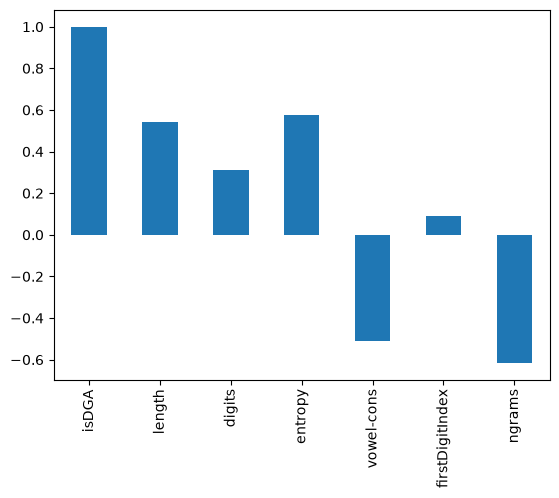

In [19]:
# visualize
corr_results.plot(kind='bar');

## Correlation of Features
Now we want to know how the features are correlated with each other (as well as the target). A good way to visualize this is with a heatmap of the correlation matrix. 

1. Compute the correlations between all the features. 

In [22]:
corr_mat = df_final_int.corr()

### Visualize
2. Use the seaborn library (it is a wrapper for matplotlib) to plot these results as a heatmap.

The code is already here, but take a look at using different cmap to get different colorways. [cmap ref](https://matplotlib.org/stable/gallery/color/colormap_reference.html)

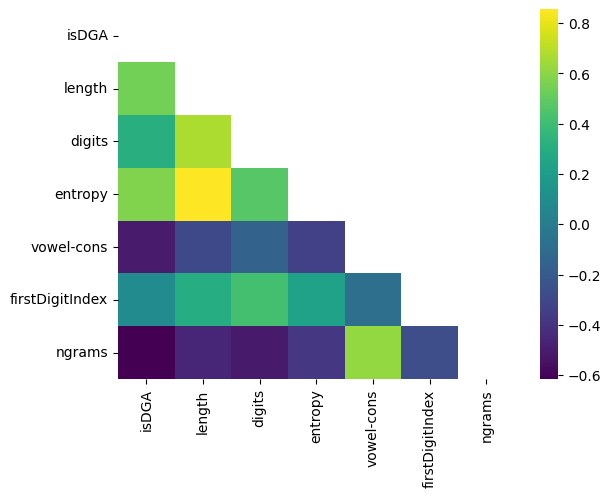

In [24]:
# Generate a mask for the upper triangle (b/c it contains the same information as the lower one. 
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

# plot a heatmap
sns.heatmap(corr_mat, mask=mask, cmap='viridis');

## Pairplot
Now let's use a Seaborn pairplot as well.  This will really show you which features have clear dividing lines between the classes.  Docs are available here: http://seaborn.pydata.org/generated/seaborn.pairplot.html

When we pass the full matrix to seaborn (notice here we want to be using our string-based target variable), we need to tell it which column we want to use to color the plots. Using the target variable is key becuase it  helps us visualize the patterns according to our targets. 

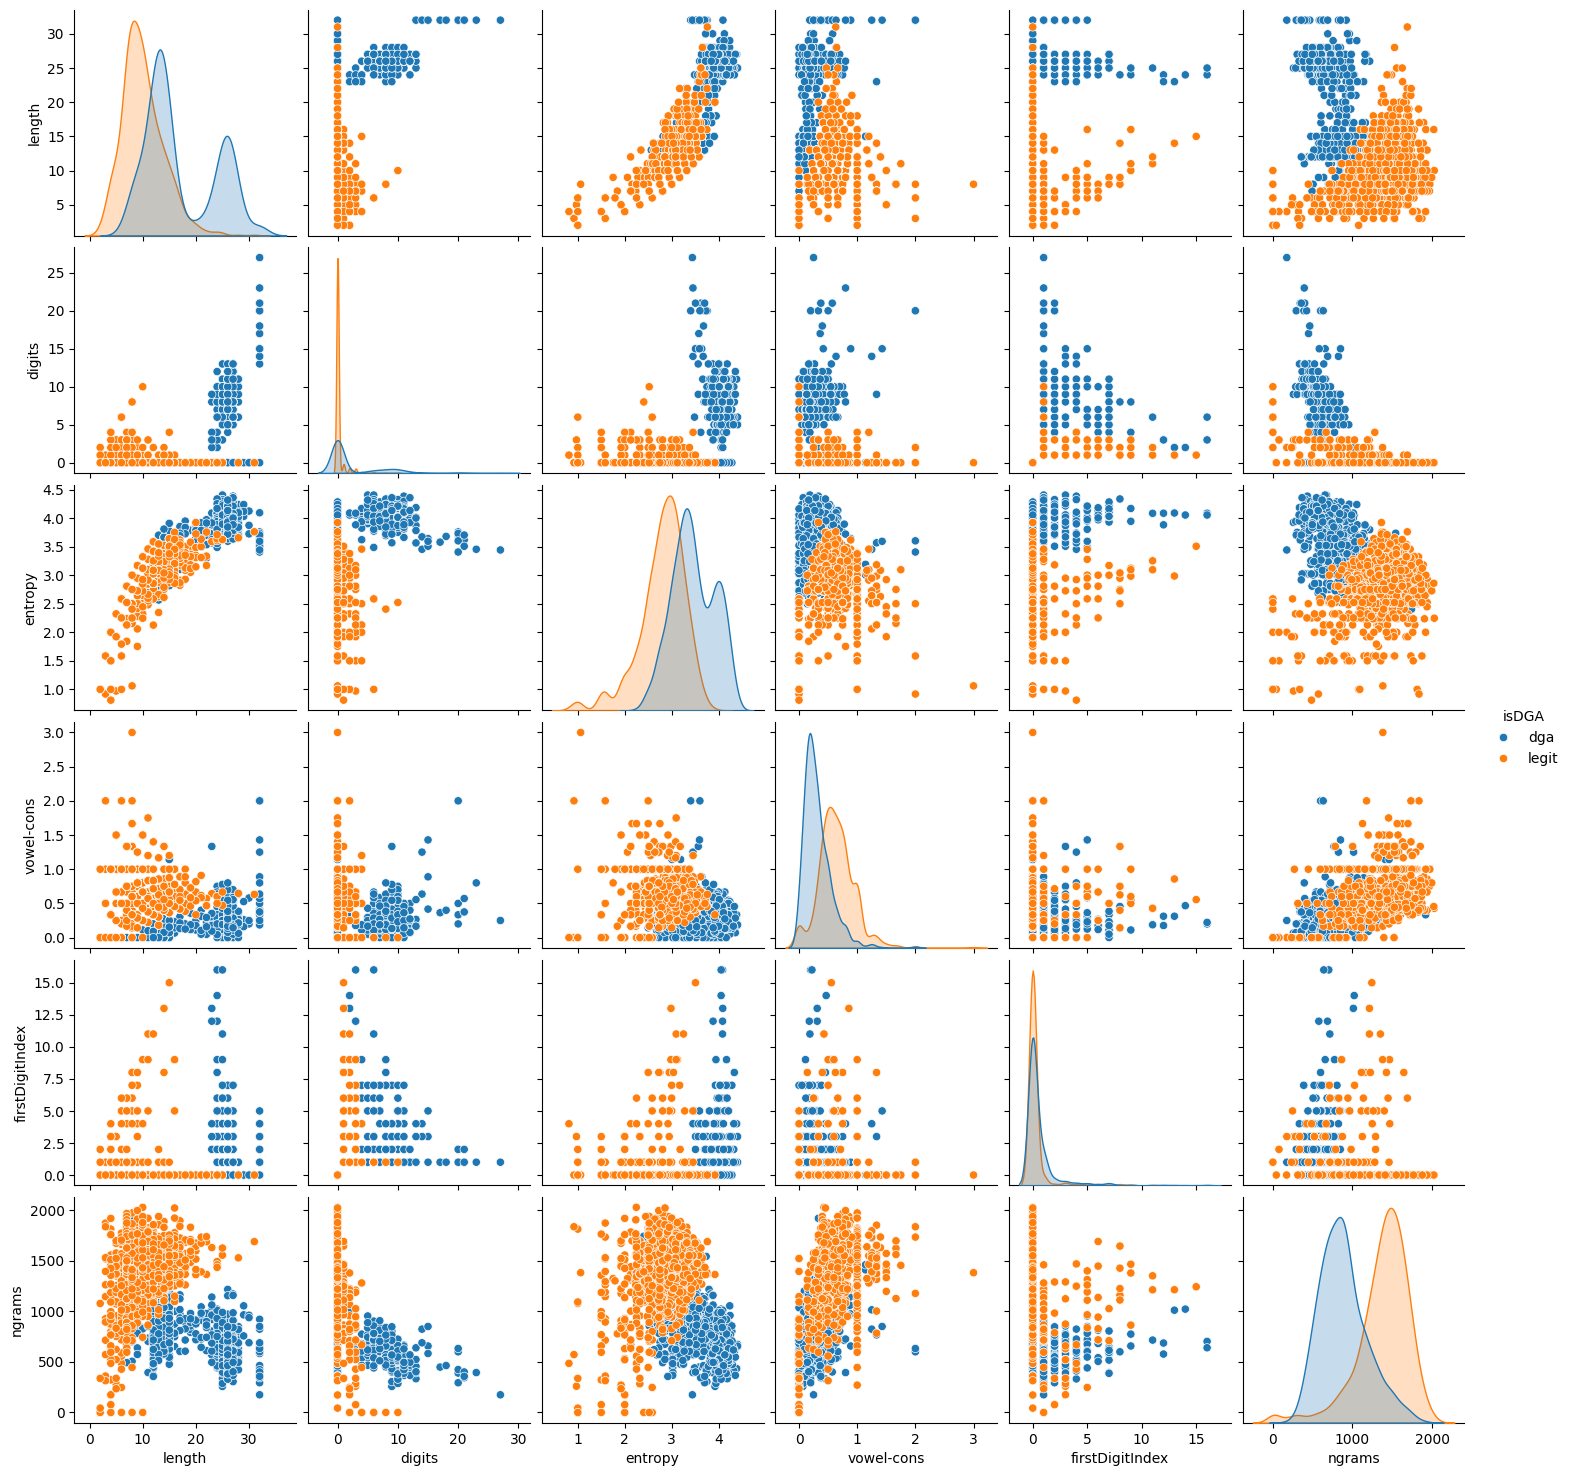

In [25]:
sns.pairplot(df_final, hue='isDGA');

Pairplots can be a little confusing. 

First, take a look at the diagonal. We see the density of each feature against our 2 target classes. If we can see that there is little overlap, then it's generally an indicator that this feature would be a good predictor of the target and is a good candidate to include in the model. 

Second, let's look at these scatter plots. You can ignor either the top or bottom diagonal b/c it's the same information. Now what we want to know is whether any of these features are contributing the same **information** about our variable. The idea is that if 2 features are highly correlated, then it's likely they contribute the same information and one could (possibly should) be removed from our model. Two correlated features will look like a diagonal line (pos or neg). 

Which feature(s) look like they are contributing similar information? 

Which features look like they would be good predictors? 

## Radviz
Finally, let's try making a RadViz (2D projection) of the features using the Pandas method ```.radviz```. 

Hoffman, P. E. et al. (1997) DNA visual and analytic data mining. In the Proceedings of the IEEE Visualization. Phoenix, AZ, pp. 437-441

Each Series in the DataFrame is represented as a evenly distributed slice on a circle. Each data point is rendered in the circle according to the value on each Series. Highly correlated Series in the DataFrame are placed closer on the unit circle.

RadViz allow to project a N-dimensional data set into a 2D space where the influence of each dimension can be interpreted as a balance between the influence of all dimensions.

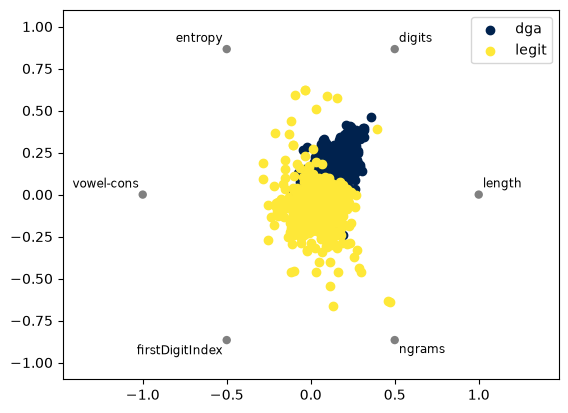

In [21]:
pd.plotting.radviz(df_final, 'isDGA', colormap='cividis');#colormap='Set3'

## Mutual Information with the Target.
This plot ranks each feature by its mutual information with isDGA, which measures how much knowing the feature reduces uncertainty about whether a domain is algorithmically generated. Unlike correlation, mutual information captures nonlinear relationships, so a feature can score highly even when its association with the target isn't monotonic ﷿﷿﷿ useful here, since DGA signals (character entropy, digit usage, length) often relate to the label in non-linear ways.  Higher values indicate features that carry more information about the class.

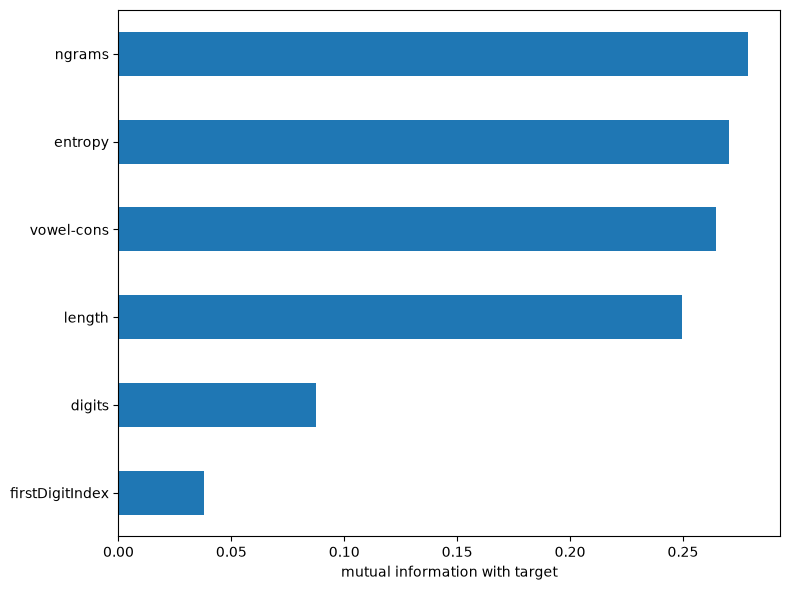

In [35]:
from sklearn.feature_selection import mutual_info_classif

features = df_final_int.drop(columns="isDGA")
target = df_final_int["isDGA"].astype(int)

mi = mutual_info_classif(features, target)
mi = pd.Series(mi, index=features.columns).sort_values()
mi.plot.barh(figsize=(8, 6))
plt.xlabel("mutual information with target")
plt.tight_layout()

## Pandas Profiling (Optional)
You've seen how to do all these steps manually. In our final example for data exploration and feature engineering, you will use a new module called FG Data Profiling to explore your data.  This module will generate much of the same information but it is a major time saver in that it will do all these calculations for you in one command.


<div class="alert alert-warning">
<strong>Warning:</strong> FG Data Profiling is not installed by default and seems to break a lot of installations.  If it is not installed on your environment, run the following command:
</div>

```bash
pip install fg-data-profiling
```

Basic usage is:

```python
profile = ProfileReport(df_final, title='Pandas Profiling Report')
```

In the cell below, execute this command and take a look at the report which is generated to see if you can find any insights about the features we've generated.  After looking at all this, do you think these features will be good enough?


Documentation is available here: https://github.com/Data-Centric-AI-Community/fg-data-profiling

In [22]:
# if you are getting errors running the cell below, try one of these commands to get the versioning of the libraries correct for fg-data-profiling to work
#!pip install fg-data-profiling
#!pip install --upgrade fg-data-profiling

In [ ]:
from data_profiling import ProfileReport
profile = ProfileReport(df_final, title="DGA Feature Profiling Report")

## Congrats!
Congrats!  You've now extracted features from the dataset and are ready to begin creating some supervised models!